In [33]:
#inportation bibliotheques
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
from sklearn.metrics import  r2_score
from scipy.stats import chi2_contingency


In [34]:
f_path = 'heart_disease_uci.csv'
data = pd.read_csv(f_path)

# Affichage
data.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
# info sur data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


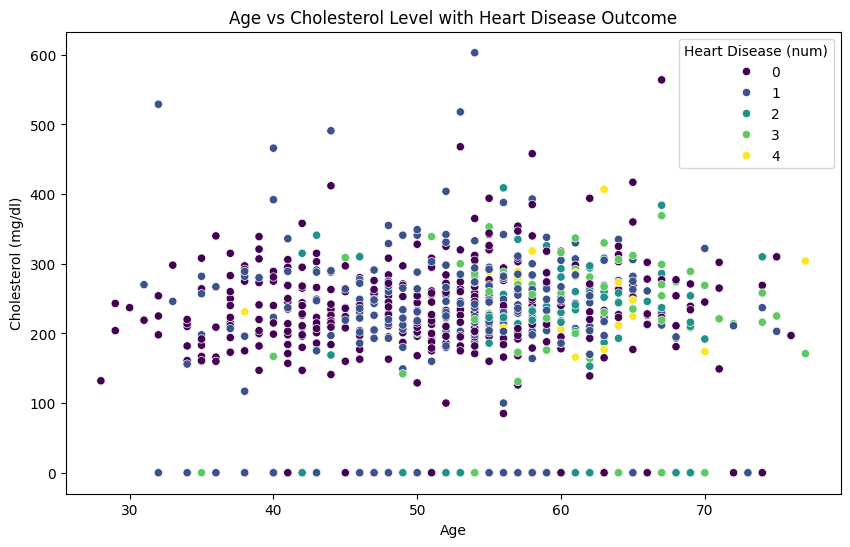

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='age', y='chol', hue='num', palette='viridis')

#titles and labels
plt.title('Age vs Cholesterol Level with Heart Disease Outcome')
plt.xlabel('Age')
plt.ylabel('Cholesterol (mg/dl)')

#plot
plt.legend(title='Heart Disease (num)')
plt.show()

In [37]:
#calculer les valeurs  null
data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [38]:
#suppression les valeurs null
data.dropna(axis=0, inplace=True)

In [39]:
#calculer les valeurs  null
data.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [40]:
label_encoders = {}
# Encode the 'dataset' column
le_dataset = LabelEncoder()
data['dataset'] = le_dataset.fit_transform(data['dataset'])
label_encoders['dataset'] = le_dataset
#-----
# Encode categorical variables

for column in ['sex', 'cp', 'restecg', 'slope', 'thal']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [41]:
# definir les features et les variables cibles
X = data.drop(['id', 'num'], axis=1)
y = data['num']

# division en donnes d'entrenement et de tests
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standrisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5], y_train[:5]

(array([[ 0.77433788, -1.4787382 , -0.08711219, -0.92715025,  0.44011936,
          0.40631763, -0.44158804, -0.97217794,  0.51199981, -0.72941845,
          2.11842411, -2.21369107,  1.32780187, -0.56218498],
        [ 0.88326475, -1.4787382 , -0.08711219,  0.0321091 ,  0.44011936,
         -0.96592853, -0.44158804,  0.96407646,  1.33675722, -0.72941845,
         -0.90930364,  1.01235872,  1.32780187, -0.56218498],
        [ 1.21004536,  0.67625223, -0.08711219,  0.0321091 ,  1.57422748,
         -0.00723601, -0.44158804,  0.96407646, -1.22433158,  1.37095517,
         -0.90930364, -0.60066618,  2.36487588, -2.28477741],
        [-1.5131264 ,  0.67625223, -0.08711219,  0.99136844, -1.147632  ,
          0.06795556, -0.44158804,  0.96407646,  1.33675722, -0.72941845,
         -0.90930364,  1.01235872, -0.74634615, -0.56218498],
        [ 1.53682597, -1.4787382 , -0.08711219,  1.95062779,  0.44011936,
         -0.13882126, -0.44158804,  0.96407646,  0.12132525, -0.72941845,
          0.

In [42]:

extraTrees_classifier = ExtraTreesClassifier(random_state=42)
#entrainer le modele
extraTrees_classifier.fit(X_train_scaled, y_train)
#prediction d'ensemble de tests
y_pred = extraTrees_classifier.predict(X_test_scaled)

# evaluation du model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report

(0.65,
 '              precision    recall  f1-score   support\n\n           0       0.87      0.94      0.90        35\n           1       0.36      0.31      0.33        13\n           2       0.22      0.40      0.29         5\n           3       0.00      0.00      0.00         4\n           4       0.00      0.00      0.00         3\n\n    accuracy                           0.65        60\n   macro avg       0.29      0.33      0.30        60\nweighted avg       0.60      0.65      0.62        60\n')

In [43]:
# Imputation les valeurs manquantes avec le mean de chaque colonne
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# entrainement du model 2eme fois avec imputed data
extraTrees_classifier.fit(X_train_imputed, y_train)

# prediction tests avec imputed data
y_pred = extraTrees_classifier.predict(X_test_imputed)

# Re-evaluation du model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report


(0.65,
 '              precision    recall  f1-score   support\n\n           0       0.87      0.94      0.90        35\n           1       0.36      0.31      0.33        13\n           2       0.22      0.40      0.29         5\n           3       0.00      0.00      0.00         4\n           4       0.00      0.00      0.00         3\n\n    accuracy                           0.65        60\n   macro avg       0.29      0.33      0.30        60\nweighted avg       0.60      0.65      0.62        60\n')

<Axes: >

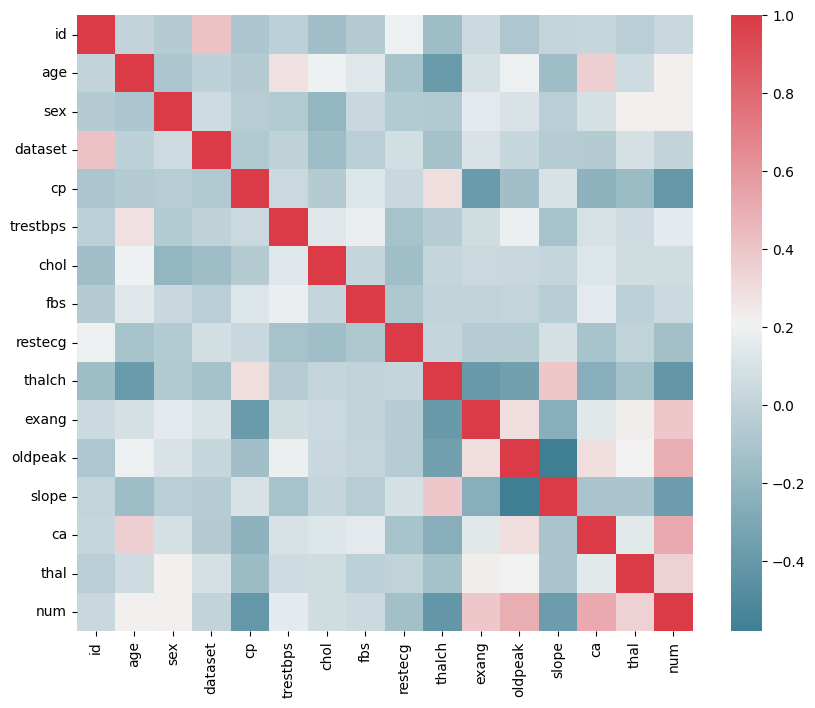

In [44]:
'''Affichage matrice de correlation et verifier s'il y a une forte liason entres 
des colonnes on les supprimes 
'''
f, ax = plt.subplots(figsize=(10, 8))
# trouver correlation
corr = data.corr()
# plotting la correlation
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)

In [45]:
# Créer un tableau de contingence entre 'sex' et 'num'
contingency_table = pd.crosstab(data['sex'], data['num'])

# Afficher le tableau de contingence
print(contingency_table)

num   0   1   2   3   4
sex                    
0    71   9   7   7   2
1    89  47  28  28  11


In [46]:
# Effectuer le test du Chi-carré
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Afficher les résultats
print(f"Statistique du Chi-carré : {chi2_stat}")
print(f"Valeur p : {p_value}")
print(f"Degrés de liberté : {dof}")
print("Tableau des fréquences attendues :")
print(expected)

Statistique du Chi-carré : 24.02756655194405
Valeur p : 7.886490534959764e-05
Degrés de liberté : 4
Tableau des fréquences attendues :
[[ 51.37123746  17.97993311  11.23745819  11.23745819   4.17391304]
 [108.62876254  38.02006689  23.76254181  23.76254181   8.82608696]]


In [47]:
# Création un tableau de contingence entre 'cp' et 'num'
contingency_table_cp = pd.crosstab(data['cp'], data['num'])

# Effectuer le test du Chi-carré
chi2_stat_cp, p_value_cp, dof_cp, expected_cp = chi2_contingency(contingency_table_cp)

# Afficher les résultats
print(f"Statistique du Chi-carré (cp vs num) : {chi2_stat_cp}")
print(f"Valeur p (cp vs num) : {p_value_cp}")

Statistique du Chi-carré (cp vs num) : 85.60131630597951
Valeur p (cp vs num) : 3.487372476467898e-13


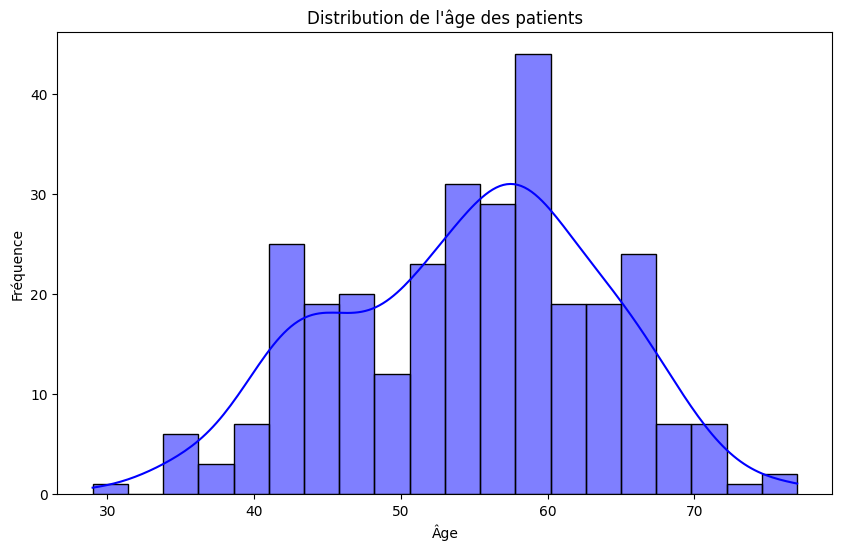

In [48]:
# Histogramme de l'âge
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True, color='blue')
plt.title('Distribution de l\'âge des patients')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

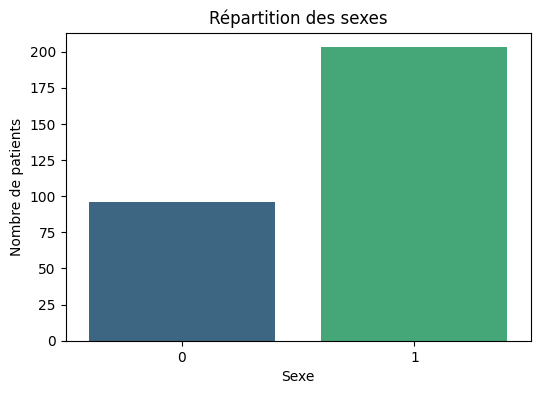

In [49]:
# Diagramme en barres du sexe
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=data, palette='viridis')
plt.title('Répartition des sexes')
plt.xlabel('Sexe')
plt.ylabel('Nombre de patients')
plt.show()

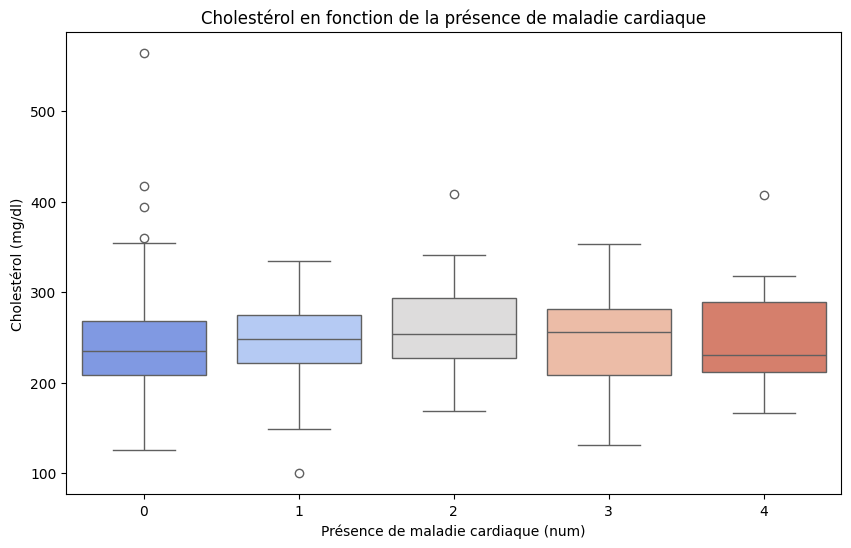

In [50]:
# Boxplot du cholestérol par présence de maladie cardiaque
plt.figure(figsize=(10, 6))
sns.boxplot(x='num', y='chol', data=data, palette='coolwarm')
plt.title('Cholestérol en fonction de la présence de maladie cardiaque')
plt.xlabel('Présence de maladie cardiaque (num)')
plt.ylabel('Cholestérol (mg/dl)')
plt.show()

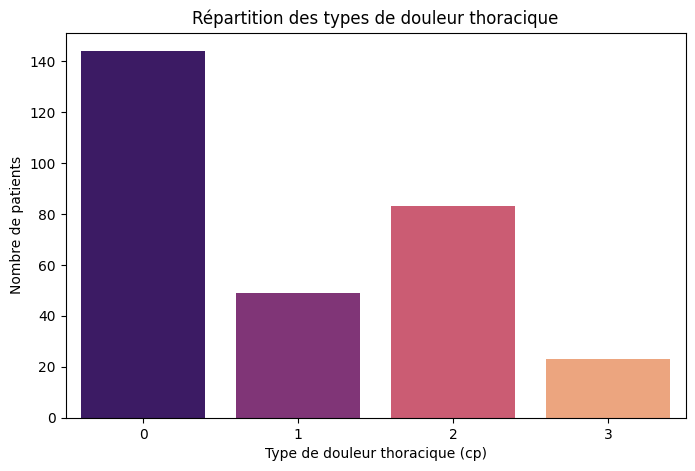

In [51]:
# Diagramme en barres du type de douleur thoracique
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', data=data, palette='magma')
plt.title('Répartition des types de douleur thoracique')
plt.xlabel('Type de douleur thoracique (cp)')
plt.ylabel('Nombre de patients')
plt.show()

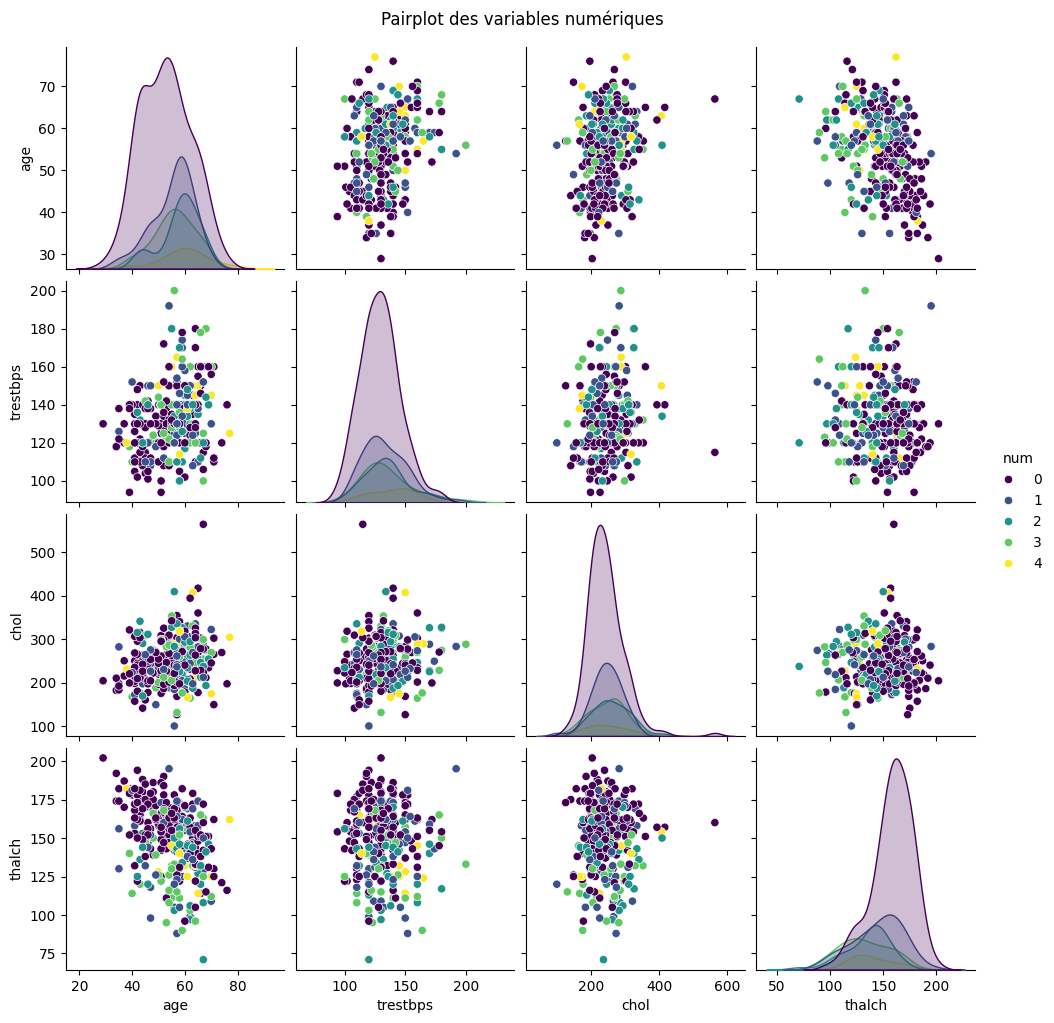

In [52]:
# Pairplot pour visualiser les relations entre plusieurs variables
sns.pairplot(data[['age', 'trestbps', 'chol', 'thalch', 'num']], hue='num', palette='viridis')
plt.suptitle('Pairplot des variables numériques', y=1.02)
plt.show()

In [53]:
from scipy.stats import chi2_contingency

# Sélectionner les variables catégorielles
categorical_columns = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'num']

# Créer une table de contingence pour chaque paire de variables
results = []
for col in categorical_columns:
    if col != 'num':  # Tester chaque variable contre la variable cible 'num'
        contingency_table = pd.crosstab(data[col], data['num'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        results.append((col, chi2, p, dof))

# Afficher les résultats
results_df = pd.DataFrame(results, columns=['Variable', 'Chi2 Statistic', 'P-Value', 'Degrees of Freedom'])
print(results_df)

  Variable  Chi2 Statistic       P-Value  Degrees of Freedom
0      sex       24.027567  7.886491e-05                   4
1  dataset        8.737013  3.649647e-01                   8
2       cp       85.601316  3.487372e-13                  12
3      fbs        8.260202  8.249846e-02                   4
4  restecg       19.144733  1.410449e-02                   8
5    exang       59.067561  4.554312e-12                   4
6    slope       54.717330  5.010071e-09                   8
7     thal       98.617769  8.179518e-18                   8


In [54]:
'''
Interprétation :
sex, cp, restecg, et exang sont significativement associés à la présence de maladie cardiaque (num).
fbs n'est pas significativement associé à num.
'''

"\nInterprétation :\nsex, cp, restecg, et exang sont significativement associés à la présence de maladie cardiaque (num).\nfbs n'est pas significativement associé à num.\n"

In [55]:
extraTrees_classifier = ExtraTreesClassifier(n_estimators=100, random_state=42)

# trainier Extra tree
extraTrees_classifier.fit(X_train, y_train)

ExtraTreesClassifier(random_state=42)

Accuracy: 0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90        35
           1       0.36      0.31      0.33        13
           2       0.22      0.40      0.29         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3

    accuracy                           0.65        60
   macro avg       0.29      0.33      0.30        60
weighted avg       0.60      0.65      0.62        60

Confusion Matrix:
 [[33  1  1  0  0]
 [ 3  4  4  2  0]
 [ 1  2  2  0  0]
 [ 1  2  1  0  0]
 [ 0  2  1  0  0]]


-------------------Matrice de Confusion--------




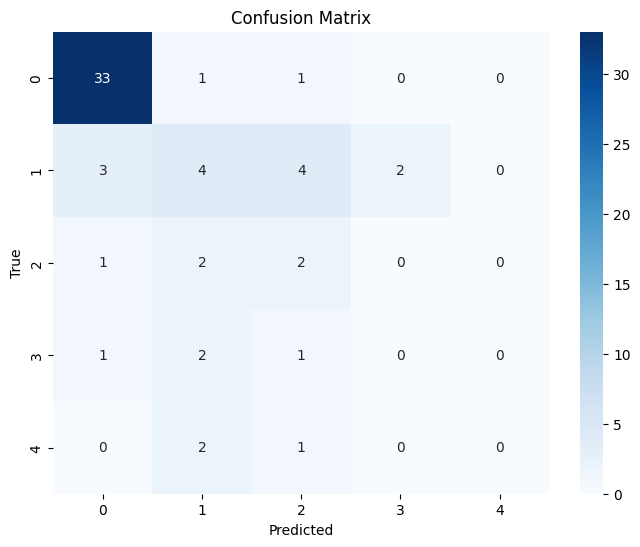

In [56]:
# faire du preduction
y_pred = extraTrees_classifier.predict(X_test)

# Evaluation du model
cm=confusion_matrix(y_test, y_pred)
accu_sk=accuracy_score(y_test, y_pred)
print("Accuracy:",accu_sk)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", cm)

#PLOT Matrice de Confusion
print('\n\n-------------------Matrice de Confusion--------\n\n')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

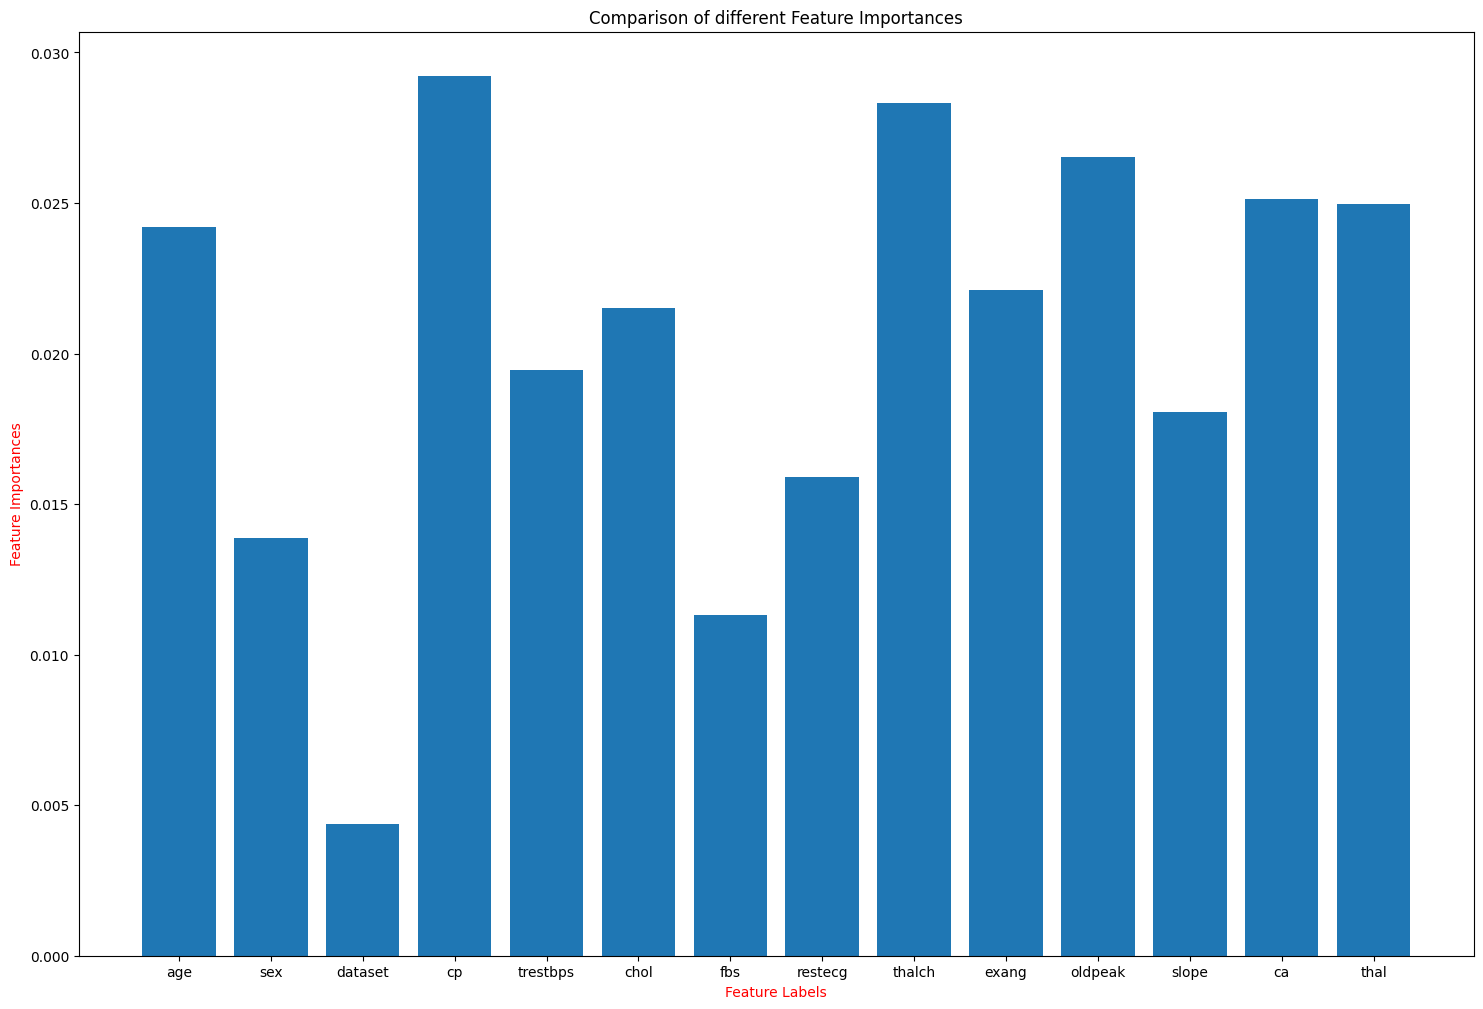

In [57]:
# calculationde l'importance de chaque feature
feature_importance = extraTrees_classifier.feature_importances_
 
# normalization de l'inportance indviduel
feature_importance_normalized = np.std([tree.feature_importances_ for tree in
                                        extraTrees_classifier.estimators_],
                                        axis = 0)
plt.figure(figsize=(18, 12))
plt.bar(X_train.columns, feature_importance_normalized)
plt.xlabel('Feature Labels',color='red')
plt.ylabel('Feature Importances',color='red')
plt.title('Comparison of different Feature Importances')
plt.show()

In [58]:
import numpy as np
from collections import Counter

def create_extra_trees(n_estimators=100, max_depth=None, min_samples_split=2, random_state=None):
    return {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "random_state": random_state,
        "trees": []
    }

def fit_extra_trees(model, X, y):
    np.random.seed(model["random_state"])
    model["trees"] = [grow_tree(X, y, model["max_depth"], model["min_samples_split"]) for _ in range(model["n_estimators"])]

def grow_tree(X, y, max_depth, min_samples_split, depth=0):
    n_samples, n_features = X.shape
    n_labels = len(np.unique(y))

    # Stopping conditions
    if (depth >= max_depth if max_depth is not None else False) or n_labels == 1 or n_samples < min_samples_split:
        return {"leaf": True, "value": most_common_label(y)}

    # Randomly select features
    feature_indices = np.random.choice(n_features, size=int(np.sqrt(n_features)), replace=False)
    best_feature, best_threshold = best_split(X, y, feature_indices)

    if best_feature is None:
        return {"leaf": True, "value": most_common_label(y)}

    # Split dataset
    left_indices = X[:, best_feature] < best_threshold
    right_indices = X[:, best_feature] >= best_threshold

    # Recursively grow left and right subtrees
    left_subtree = grow_tree(X[left_indices], y[left_indices], max_depth, min_samples_split, depth + 1)
    right_subtree = grow_tree(X[right_indices], y[right_indices], max_depth, min_samples_split, depth + 1)

    return {"leaf": False, "feature": best_feature, "threshold": best_threshold, "left": left_subtree, "right": right_subtree}

def best_split(X, y, feature_indices):
    best_gini = float("inf")
    best_feature, best_threshold = None, None

    for feature_index in feature_indices:
        thresholds = np.unique(X[:, feature_index])
        for threshold in thresholds:
            left_indices = X[:, feature_index] < threshold
            right_indices = X[:, feature_index] >= threshold

            if sum(left_indices) == 0 or sum(right_indices) == 0:
                continue

            gini = gini_impurity(y[left_indices], y[right_indices])
            if gini < best_gini:
                best_gini, best_feature, best_threshold = gini, feature_index, threshold

    return best_feature, best_threshold

def gini_impurity(left_labels, right_labels):
    n_left, n_right = len(left_labels), len(right_labels)
    n_total = n_left + n_right

    gini_left = 1 - sum((np.sum(left_labels == label) / n_left) ** 2 for label in np.unique(left_labels))
    gini_right = 1 - sum((np.sum(right_labels == label) / n_right) ** 2 for label in np.unique(right_labels))

    return (n_left / n_total) * gini_left + (n_right / n_total) * gini_right

def most_common_label(y):
    return Counter(y).most_common(1)[0][0]

def predict_extra_trees(model, X):
    predictions = np.array([[predict_sample(tree, x) for tree in model["trees"]] for x in X])
    return np.array([Counter(predictions[i]).most_common(1)[0][0] for i in range(X.shape[0])])

def predict_sample(tree, x):
    if tree["leaf"]:
        return tree["value"]
    
    feature_value = x[tree["feature"]]
    if feature_value < tree["threshold"]:
        return predict_sample(tree["left"], x)
    else:
        return predict_sample(tree["right"], x)

In [59]:
# Create the model
model = create_extra_trees(n_estimators=100, max_depth=10, random_state=42)

# Train the model
fit_extra_trees(model, X_train_imputed, y_train)

# Make predictions
y_pred_model = predict_extra_trees(model, X_test_imputed)

# Print completion message
print("Training Completed!")


Training Completed!


In [60]:
# Evaluation du model
from sklearn.metrics import accuracy_score
print("Accuracy from From Scratch :", accuracy_score(y_test, y_pred_model))
print('------------------------------------')
print("Classification Report From Scratch:\n", classification_report(y_test, y_pred))
print('------------------------------------')
print("Accuracy from Sklearn:",accu_sk)

Accuracy from From Scratch : 0.6166666666666667
------------------------------------
Classification Report From Scratch:
               precision    recall  f1-score   support

           0       0.87      0.94      0.90        35
           1       0.36      0.31      0.33        13
           2       0.22      0.40      0.29         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3

    accuracy                           0.65        60
   macro avg       0.29      0.33      0.30        60
weighted avg       0.60      0.65      0.62        60

------------------------------------
Accuracy from Sklearn: 0.65


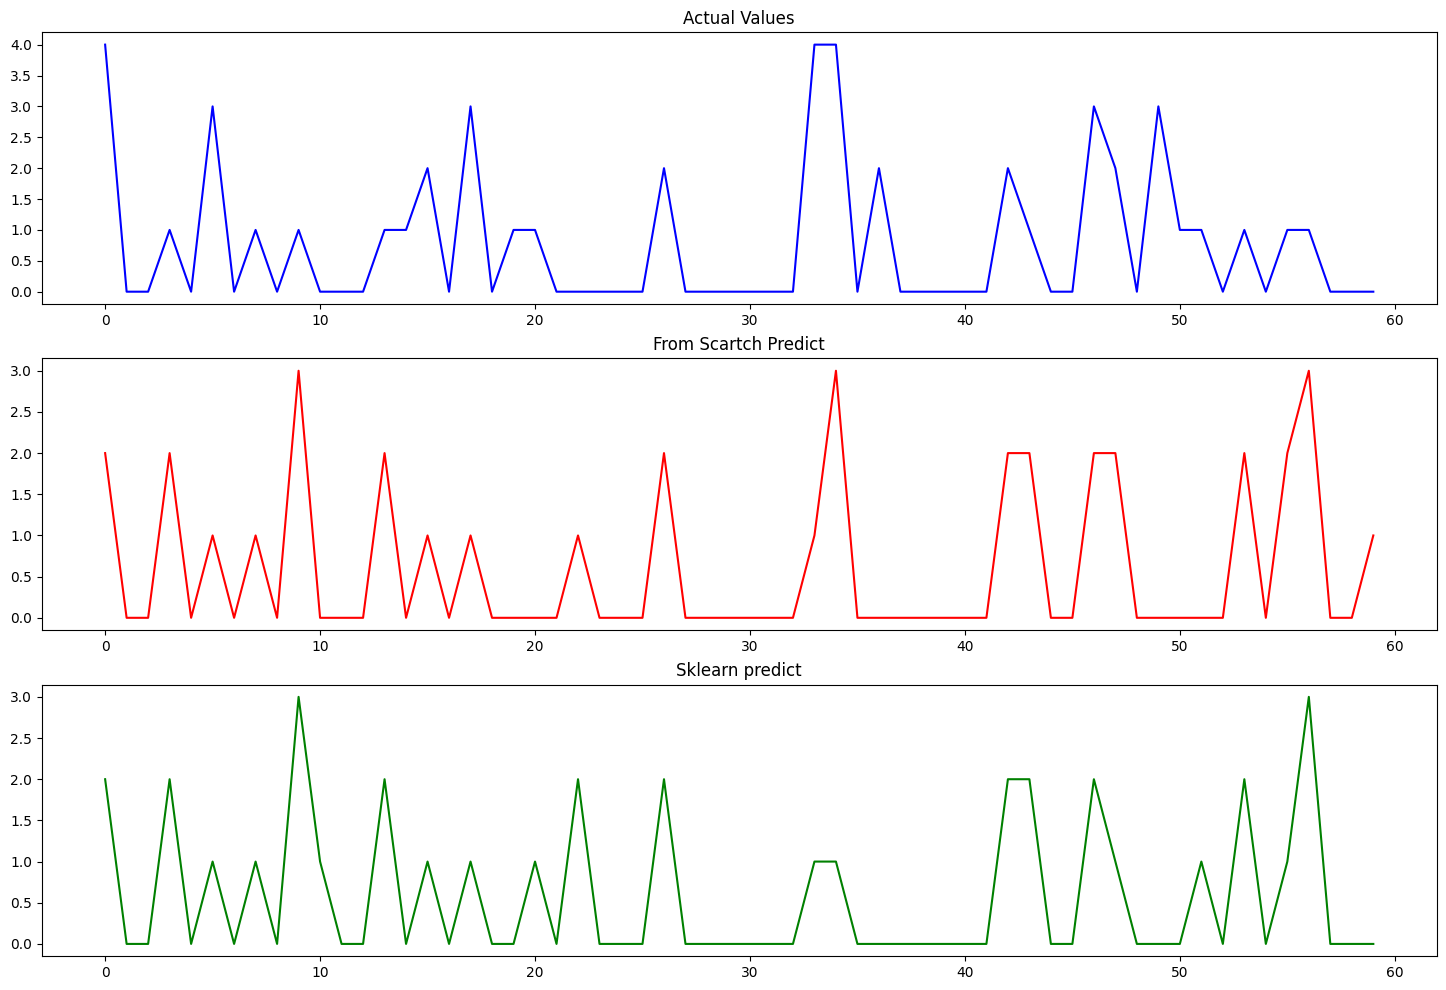

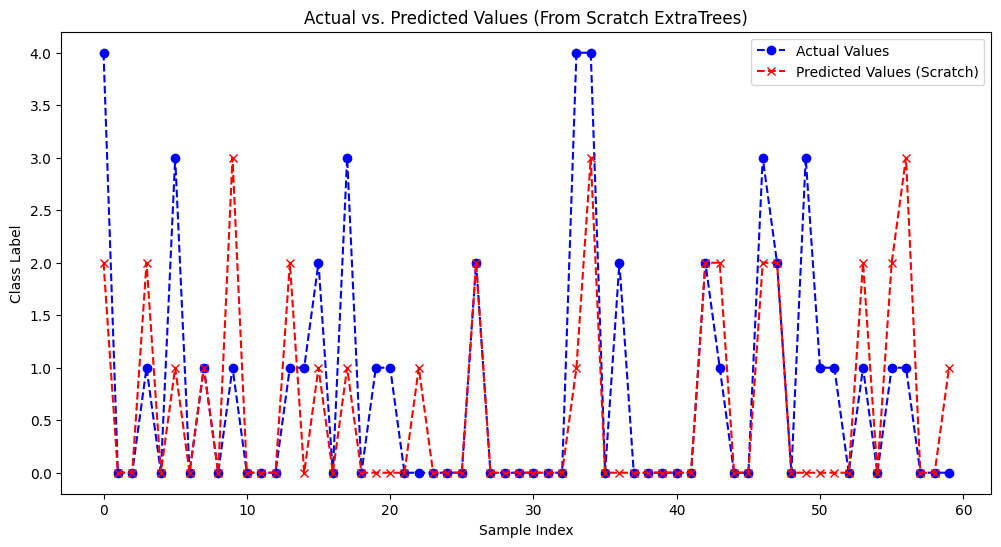

In [61]:
plt.figure(figsize=(18, 12))
# plotting the graphs
plt.subplot(3, 1, 1)
plt.plot([i for i in range(len(y_test))],y_test, color = 'blue',label="actual values")
plt.title("Actual Values")
plt.subplot(3, 1, 2)
plt.plot([i for i in range(len(y_test))],y_pred_model, color='red', label="Predicted values From Scratch")
plt.title("From Scartch Predict")
plt.subplot(3, 1, 3)
plt.plot([i for i in range(len(y_test))],y_pred, color='green', label="Predicted values Sklearn")
plt.title("Sklearn predict")

plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test, color='blue', label="Actual Values", marker='o', linestyle="dashed")

# Plot predicted values (from our scratch implementation)
plt.plot(range(len(y_test)), y_pred_model, color='red', label="Predicted Values (Scratch)", marker='x', linestyle="dashed")

plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.title("Actual vs. Predicted Values (From Scratch ExtraTrees)")


# showing the plotting
plt.legend()
plt.show()

In [62]:
from sklearn.metrics import hamming_loss
from sklearn.metrics import log_loss
from sklearn.metrics import matthews_corrcoef



print('\n          Hamming Loss\n')
hamming_loss_scratch = hamming_loss(y_test, y_pred_model)
hamming_loss_sklearn = hamming_loss(y_test, y_pred)
print(f"Hamming Loss scratch: {hamming_loss_scratch}\nHamming Loss sklearn: {hamming_loss_sklearn}")
'''
log_loss_value = log_loss(y_test, y_pred_model)
print(f"Log Loss: {log_loss_value}")
'''
print('\n          Matthews Correlation Coefficient\n')
mccS = matthews_corrcoef(y_test, y_pred_model)
mccSk = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient scratch: {mccS}\nMatthews Correlation Coefficient sklearn: {mccSk}")


          Hamming Loss

Hamming Loss scratch: 0.38333333333333336
Hamming Loss sklearn: 0.35

          Matthews Correlation Coefficient

Matthews Correlation Coefficient scratch: 0.3347007170146578
Matthews Correlation Coefficient sklearn: 0.3969928828479428


In [63]:
# Generate random data (as provided)
np.random.seed(42)
n_samples = 100  # Number of samples
n_features = 14  # Number of features (excluding 'id' and 'num')

random_data = {
    'age': np.random.randint(20, 80, size=n_samples),
    'sex': np.random.choice(['Male', 'Female'], size=n_samples),
    'dataset': np.random.choice(['Cleveland', 'Hungarian', 'Switzerland'], size=n_samples),
    'cp': np.random.choice(['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'], size=n_samples),
    'trestbps': np.random.uniform(90, 200, size=n_samples),
    'chol': np.random.uniform(100, 600, size=n_samples),
    'fbs': np.random.choice([True, False], size=n_samples),
    'restecg': np.random.choice(['normal', 'ST-T wave abnormality', 'left ventricular hypertrophy'], size=n_samples),
    'thalch': np.random.uniform(60, 220, size=n_samples),
    'exang': np.random.choice(['Yes', 'No'], size=n_samples),
    'oldpeak': np.random.uniform(0, 6, size=n_samples),
    'slope': np.random.choice(['upsloping', 'flat', 'downsloping'], size=n_samples),
    'ca': np.random.uniform(0, 4, size=n_samples),
    'thal': np.random.choice(['normal', 'fixed defect', 'reversable defect'], size=n_samples)
}

# Convert to DataFrame
random_df = pd.DataFrame(random_data)

# Encoding Categorical Variables
label_encoders = {}
for column in ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal', 'exang', 'fbs']:
    le = LabelEncoder()
    random_df[column] = le.fit_transform(random_df[column])
    label_encoders[column] = le

#Defining Features (X) and Target (y)
# Let's assume 'age' is the target variable for this example
X = random_df.drop('age', axis=1)  # Features (all columns except 'age')
y = random_df['age']  # Target variable

#Spliting the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Training the Extra Trees Model
model = create_extra_trees(n_estimators=100, max_depth=10, random_state=42)
fit_extra_trees(model, X_train.values, y_train.values)

#Making Predictions
y_pred = predict_extra_trees(model, X_test.values)

#Evaluating the Model
# Since this is a regression problem (predicting 'age'), we can use Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

# Optional: Print Actual vs Predicted Values
print("\nActual vs Predicted Values:")
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual}, Predicted: {predicted}")

Mean Absolute Error: 16.75

Actual vs Predicted Values:
Actual: 25, Predicted: 71
Actual: 40, Predicted: 66
Actual: 79, Predicted: 54
Actual: 63, Predicted: 48
Actual: 70, Predicted: 55
Actual: 47, Predicted: 39
Actual: 43, Predicted: 43
Actual: 59, Predicted: 28
Actual: 42, Predicted: 34
Actual: 58, Predicted: 71
Actual: 22, Predicted: 27
Actual: 31, Predicted: 37
Actual: 27, Predicted: 23
Actual: 63, Predicted: 63
Actual: 45, Predicted: 26
Actual: 62, Predicted: 79
Actual: 33, Predicted: 48
Actual: 36, Predicted: 53
Actual: 30, Predicted: 21
Actual: 77, Predicted: 21


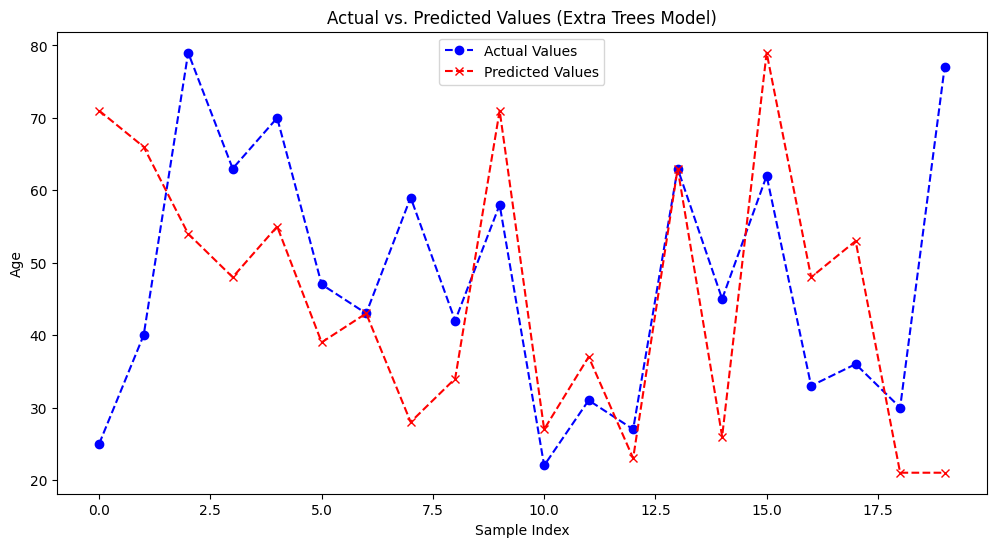

In [64]:
# Line Plot for Actual vs Predicted Values
plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test, color='blue', label="Actual Values", marker='o', linestyle="dashed")

# Plot predicted values
plt.plot(range(len(y_test)), y_pred, color='red', label="Predicted Values", marker='x', linestyle="dashed")

# Add labels and title
plt.xlabel("Sample Index")
plt.ylabel("Age")
plt.title("Actual vs. Predicted Values (Extra Trees Model)")
plt.legend()

# Show the plot
plt.show()